Objective of this notebook is to create a baseline model with minimal cleaning and feature engineering, of which the results can then be used to compare future models against.

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [197]:
#Load Dataset
ufc_dataset_df = pd.read_csv('data/ufc-master.csv')

In [198]:
print(ufc_dataset_df.shape)

(4896, 119)


In [199]:
ufc_dataset_df.dtypes

R_fighter                        object
B_fighter                        object
R_odds                          float64
B_odds                            int64
R_ev                            float64
B_ev                            float64
date                             object
location                         object
country                          object
Winner                           object
title_bout                         bool
weight_class                     object
gender                           object
no_of_rounds                      int64
B_current_lose_streak             int64
B_current_win_streak              int64
B_draw                            int64
B_avg_SIG_STR_landed            float64
B_avg_SIG_STR_pct               float64
B_avg_SUB_ATT                   float64
B_avg_TD_landed                 float64
B_avg_TD_pct                    float64
B_longest_win_streak              int64
B_losses                          int64
B_total_rounds_fought             int64


In [200]:
#Preview Data
pd.set_option('display.max_columns', None)
ufc_dataset_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Light Heavyweight,MALE,5,0,1,0,3.42,0.59,0.7,0.24,1.00,4,2,11,0,0,0,1,4,0,0,5,Orthodox,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,Orthodox,187.96,193.04,205,37,29,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,1,10.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,3,2,0,0,5.16,0.42,0.8,0.79,0.22,2,5,24,0,0,0,0,4,2,0,6,Orthodox,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,Orthodox,180.34,193.04,170,33,32,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,1,0,0,2.92,0.41,0.1,1.15,0.34,5,5,38,0,0,2,6,1,0,0,9,Southpaw,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,Orthodox,190.50,195.58,205,34,32,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,S-DEC,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Lightweight,MALE,3,1,0,0,4.04,0.34,0.0,0.00,0.00,0,1,3,0,0,0,0,0,0,0,0,Orthodox,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,Orthodox,175.26,182.88,155,29,32,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

EDA

Non-numeric fields will need to either be encoded or removed from the model.
We will remove details related to the fight finish as these are not available for an upcoming event
Will also drop R, B fighter stats in favour of the already available comparative stats (e.g. keep better rank instead of fights rank at the particular weight)

In [201]:
#Select subset of data
#Drop date, location , country, fighter_names for the time being as they hold string data.
#Finish Details anfd total_fight_time_secs not available in dataset for an upcoming event
my_cols = [
    'R_odds', 'B_odds', 'R_ev', 'B_ev', 'country', 'location',
	'no_of_rounds', 'B_current_lose_streak', 'B_current_win_streak',
	'B_draw', 'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct', 'B_avg_SUB_ATT', 
    'B_longest_win_streak',	'B_losses', 'B_total_rounds_fought', 
    'B_total_title_bouts', 'B_win_by_Decision_Majority', 'B_win_by_Decision_Split', 'B_win_by_Decision_Unanimous',
    'B_win_by_KO/TKO', 'B_win_by_Submission', 'B_win_by_TKO_Doctor_Stoppage', 'B_wins', 'B_Stance', 
    'B_Height_cms', 'B_Reach_cms', 'B_Weight_lbs', 'R_current_lose_streak', 'R_current_win_streak', 
    'R_draw', 'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct', 'R_avg_SUB_ATT', 'R_avg_TD_landed', 'R_avg_TD_pct',	
    'R_longest_win_streak', 'R_losses',	'R_total_rounds_fought', 'R_total_title_bouts', 'R_win_by_Decision_Majority',	
    'R_win_by_Decision_Split', 'R_win_by_Decision_Unanimous', 'R_win_by_KO/TKO', 'R_win_by_Submission',
    'R_win_by_TKO_Doctor_Stoppage', 'R_wins', 'R_Stance', 'R_Height_cms', 'R_Reach_cms', 'R_Weight_lbs', 
    'R_age', 'B_age', 'lose_streak_dif', 'win_streak_dif','longest_win_streak_dif', 'win_dif', 'loss_dif'	
    'total_round_dif', 'total_title_bout_dif', 'ko_dif', 'sub_dif', 'height_dif', 
    'reach_dif', 'age_dif', 'sig_str_dif', 'avg_sub_att_dif', 'avg_td_dif',	
    'empty_arena', 'B_match_weightclass_rank',	
    'R_match_weightclass_rank',  'R_Pound-for-Pound_rank', 'B_Pound-for-Pound_rank',
	'B_avg_TD_landed', 'B_avg_TD_pct',  
    'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
    'b_sub_odds', 'r_ko_odds', 'b_ko_odds', 
    'weight_class', 'gender', 'title_bout', 'better_rank', 'Winner'
    ]
																
clean_ufc_df = pd.DataFrame(data= ufc_dataset_df, columns=my_cols)
#clean_ufc_df = pd.DataFrame(data= ufc_dataset_df, columns=numeric_col)
clean_ufc_df.head()


,R_odds,B_odds,R_ev,B_ev,country,location,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_diftotal_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Pound-for-Pound_rank,B_Pound-for-Pound_rank,B_avg_TD_landed,B_avg_TD_pct,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,weight_class,gender,title_bout,better_rank,Winner
0,-150.0,130,66.666667,130.000000,USA,"Las Vegas, Nevada, USA",5,0,1,0,3.42,0.59,0.7,4,2,11,0,0,0,1,4,0,0,5,Orthodox,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,Orthodox,187.96,193.04,205,37,29,-3,1,0,-8,NaN,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,10.0,5.0,NaN,NaN,0.24,1.00,800.0,900.0,2000.0,1600.0,-110.0,175.0,Light Heavyweight,MALE,False,Red,Red
1,170.0,-200,170.000000,50.000000,USA,"Las Vegas, Nevada, USA",3,2,0,0,5.16,0.42,0.8,2,5,24,0,0,0,0,4,2,0,6,Orthodox,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,Orthodox,180.34,193.04,170,33,32,0,0,-2,-5,NaN,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,NaN,NaN,NaN,NaN,0.79,0.22,450.0,350.0,700.0,1100.0,550.0,120.0,Welterweight,MALE,False,neither,Blue
2,110.0,-130,110.000000,76.923077,USA,"Las Vegas, Nevada, USA",3,1,0,0,2.92,0.41,0.1,5,5,38,0,0,2,6,1,0,0,9,Southpaw,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,Orthodox,190.50,195.58,205,34,32,0,0,1,3,NaN,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,NaN,NaN,NaN,NaN,1.15,0.34,550.0,275.0,275.0,1400.0,600.0,185.0,Middleweight,MALE,False,neither,Blue
3,-675.0,475,14.814815,475.000000,USA,"Las Vegas, Nevada, USA",3,1,0,0,4.04,0.34,0.0,0,1,3,0,0,0,0,0,0,0,0,Orthodox,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,Orthodox,175.26,182.88,155,29,32,0,0,-2,-4,NaN,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,NaN,NaN,NaN,NaN,0.00,0.00,175.0,900.0,500.0,3500.0,110.0,1100.0,Lightweight,MALE,False,neither,Red
4,-135.0,115,74.074074,115.000000,USA,"Las Vegas, Nevada, USA",3,0,2,0,5.22,0.56,0.0,2,3,19,0,0,0,4,1,0,0,5,Orthodox,175.26,172.72,145,0,4,0,2.64,0.62,0.6,2.85,0.52,4,0,8,0,0,0,2,0,2,0,4,Orthodox,175.26,177.80,155,28,33,0,-2,-2,1,NaN,0,1,-2,0.00,-5.08,5,2.58,-0.6,-0.31,1,NaN,NaN,NaN,NaN,2.54,0.39,165.0,200.0,400.0,1200.0,900.0,600.0,Lightweight,MALE,False,neither,Blue


In [202]:
#Overall Statistics
clean_ufc_df.describe()

,R_odds,B_odds,R_ev,B_ev,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_diftotal_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Pound-for-Pound_rank,B_Pound-for-Pound_rank,B_avg_TD_landed,B_avg_TD_pct,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
count,4895.000000,4896.000000,4895.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,3966.000000,4131.000000,4064.000000,4896.00000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4441.000000,4539.000000,4539.000000,4539.000000,4529.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,0.0,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,877.000000,1328.000000,166.000000,35.000000,4063.000000,4054.000000,4093.000000,4077.000000,3847.000000,3835.000000,3847.000000,3834.000000
mean,-117.640449,66.030637,94.827397,167.083323,3.181985,0.477941,0.875408,0.010621,26.308553,0.444741,0.504614,1.76491,1.726511,10.742443,0.232639,0.014502,0.260417,0.975490,0.960989,0.588848,0.029616,2.880923,178.084669,182.435958,164.803105,0.613154,1.051062,0.013480,27.396408,0.454709,0.517659,1.337388,0.329411,2.530842,2.393587,15.950980,0.552083,0.025735,0.365809,1.468750,1.449551,0.866422,0.047386,4.293709,178.030948,182.619835,165.253472,30.056985,29.518382,0.105392,-0.175449,-0.765931,-1.412786,NaN,-0.319444,-0.506332,-0.277574,0.018591,-0.251172,0.329044,-3.539160,-0.061050,-0.201570,0.138480,8.262258,6.834337,6.789157,9.485714,1.251173,0.312506,294.064745,416.544027,843.010138,1064.543155,514.231869,647.257173
std,268.881452,247.803928,82.843409,136.944643,0.571515,0.769386,1.311379,0.108333,20.935885,0.121332,0.680111,1.88258,2.080347,13.056366,1.022727,0.121255,0.577227,1.495861,1.689694,1.224983,0.176625,3.608739,8.947115,10.995139,34.362908,0.861302,1.698478,0.123872,19.871959,0.106335,0.651641,1.274270,0.228592,2.191512,2.488649,16.801419,1.499930,0.160920,0.666710,1.821404,2.074385,1.495013,0.229137,4.281123,9.026469,10.879333,34.627769,4.115818,3.982299,0.994121,1.729648,2.029394,4.030496,NaN,1.649489,2.084517,1.759247,6.963455,9.433336,5.174245,22.521709,0.848169,1.701414,0.345439,4.198510,4.613596,4.147011,4.300283,1.337641,0.249412,230.583958,306.571299,550.126761,627.285034,413.622768,458.846643
min,-1700.000000,-1200.000000,5.882353,8.333333,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.400000,0.000000,115.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.400000,152.400000,115.000000,19.000000,19

In [203]:
# Calculate the correlation matrix and take the absolute value
corr_df = numeric_data.corr()

#Inital df 
print(f"Inital Correlation matrix has {corr_df.shape[1]} columns.")

# Create a True/False mask and apply it
mask = np.triu(np.ones_like(corr_df.abs(), dtype=bool))
tri_df = corr_df.mask(mask)

# List column names of highly correlated features (r > 0.95)
to_drop = [c for c in tri_df.columns if any(tri_df[c] < 0.65)]

# Drop the features in the to_drop list
reduced_df = corr_df.drop(to_drop, axis=1)

print(f"The reduced_df DataFrame has {reduced_df.shape[1]} columns.")

reduced_df.head()

Inital Correlation matrix has 77 columns.
The reduced_df DataFrame has 2 columns.


,loss_diftotal_round_dif,title_bout
R_odds,NaN,-0.145848
B_odds,NaN,0.132267
R_ev,NaN,-0.087028
B_ev,NaN,0.160518
no_of_rounds,NaN,0.612484


<Figure size 1600x900 with 0 Axes>

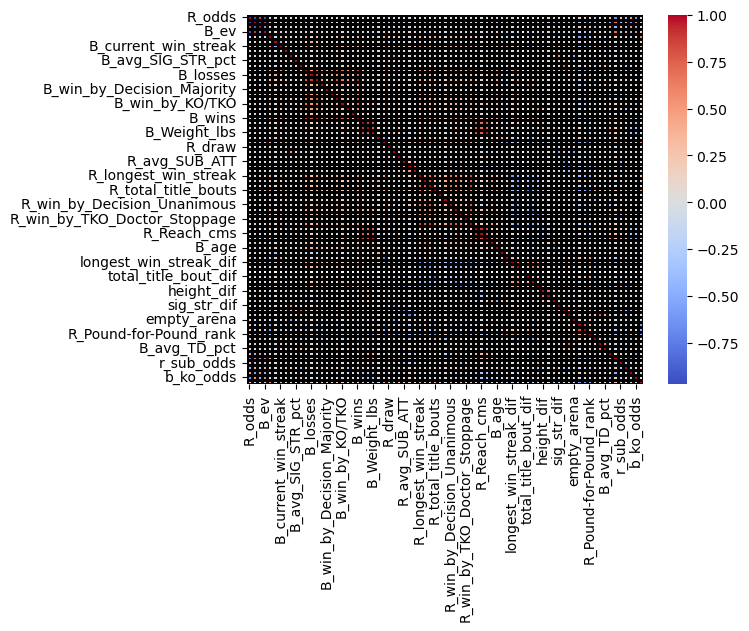

<Figure size 1600x900 with 0 Axes>

In [204]:
sns.heatmap(corr_matrix, annot=False, linewidths = 1, cmap="coolwarm", linecolor="k")
plt.figure(figsize = (16,9))

Data Preparation and Feature Engineering

In the following cells, we will: 

1. Convert categorical data into numeric data
2. Deal with the missing data in the dataset
3. Extract any relevant features that might be missing

In [205]:
X = clean_ufc_df.loc[:, clean_ufc_df.columns != 'Winner']
y = clean_ufc_df['Winner']

In [206]:
#Create Dataframe with only numeric columns in it
numeric_col = X._get_numeric_data().columns
X_numeric = pd.DataFrame(data = X, columns = numeric_col)

In [207]:
#List of categorical columns
cat_col = list(set(X.columns) - set(X_numeric))
cat_col

['B_Stance',
 'location',
 'R_Stance',
 'country',
 'better_rank',
 'weight_class',
 'gender']

In [208]:
#Asses uniqueness of categorical colums
print(f"B_Stance has {X['B_Stance'].nunique()} unique values")
print(f"location has {X['location'].nunique()} unique values")
print(f"R_stance has {X['R_Stance'].nunique()} unique values")
print(f"country has {X['country'].nunique()} unique values")
print(f"better_rank has {X['better_rank'].nunique()} unique values")
print(f"weight_class has {X['weight_class'].nunique()} unique values")
print(f"gender has {X['gender'].nunique()} unique values")


B_Stance has 5 unique values
location has 145 unique values
R_stance has 4 unique values
country has 28 unique values
better_rank has 3 unique values
weight_class has 13 unique values
gender has 2 unique values


In [209]:
#Lets remove location and country from the dataset as it has too many options and may create noise in the dataset
X = X.drop(['country','location'], axis = 1)
s = (X.dtypes == 'object')
object_cols = list(s[s].index)
print(object_cols)

['B_Stance', 'R_Stance', 'weight_class', 'gender', 'better_rank']


In [210]:
# Apply one-hot encoder to the rest of the columns with categorical data
from sklearn.preprocessing import OneHotEncoder

#create encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

#Encode Data
OH_encoded = pd.DataFrame(encoder.fit_transform(X[object_cols]))

#Get feature names
OH_encoded.columns = encoder.get_feature_names_out(object_cols)

# One-hot encoding removed index; put it back
OH_encoded.index = X.index

# Remove categorical columns (will replace with one-hot encoding)
num_X = X.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_X = pd.concat([num_X, OH_encoded], axis=1)

# Ensure all columns have string type
OH_X.columns = OH_X.columns.astype(str)

#Sample new data
OH_X.head()

,R_odds,B_odds,R_ev,B_ev,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_diftotal_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Pound-for-Pound_rank,B_Pound-for-Pound_rank,B_avg_TD_landed,B_avg_TD_pct,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,title_bout,B_Stance_Open Stance,B_Stance_Orthodox,B_Stance_Southpaw,B_Stance_Switch,B_Stance_Switch,B_Stance_nan,R_Stance_Open Stance,R_Stance_Orthodox,R_Stance_Southpaw,R_Stance_Switch,weight_class_Bantamweight,weight_class_Catch Weight,weight_class_Featherweight,weight_class_Flyweight,weight_class_Heavyweight,weight_class_Light Heavyweight,weight_class_Lightweight,weight_class_Middleweight,weight_class_Welterweight,weight_class_Women's Bantamweight,weight_class_Women's Featherweight,weight_class_Women's Flyweight,weight_class_Women's Strawweight,gender_FEMALE,gender_MALE,better_rank_Blue,better_rank_Red,better_rank_neither
0,-150.0,130,66.666667,130.000000,5,0,1,0,3.42,0.59,0.7,4,2,11,0,0,0,1,4,0,0,5,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,187.96,193.04,205,37,29,-3,1,0,-8,NaN,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,10.0,5.0,NaN,NaN,0.24,1.00,800.0,900.0,2000.0,1600.0,-110.0,175.0,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,170.0,-200,170.000000,50.000000,3,2,0,0,5.16,0.42,0.8,2,5,24,0,0,0,0,4,2,0,6,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,180.34,193.04,170,33,32,0,0,-2,-5,NaN,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,NaN,NaN,NaN,NaN,0.79,0.22,450.0,350.0,700.0,1100.0,550.0,120.0,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,110.0,-130,110.000000,76.923077,3,1,0,0,2.92,0.41,0.1,5,5,38,0,0,2,6,1,0,0,9,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,190.50,195.58,205,34,32,0,0,1,3,NaN,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,NaN,NaN,NaN,NaN,1.15,0.34,550.0,275.0,275.0,1400.0,600.0,185.0,False,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-675.0,475,14.814815,475.000000,3,1,0,0,4.04,0.34,0.0,0,1,3,0,0,0,0,0,0,0,0,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,175.26,182.88,155,29,32,0,0,-2,-4,NaN,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,NaN,NaN,NaN,NaN,0.00,0.00,175.0,900.0,500.0,3500.0,110.0,1100.0,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-135.0,115,74.074074,115.000000,3,0,2,0,5.22,0.56,0.0,2,3,19,0,0,0,4,1,0,0,5,175.26,172.72,145,0,4,0,2.64,0.62,0.6,2.85,0.52,4,0,8,0,0,0,2,0,2,0,4,175.26,177.80,155,28,33,0,-2,-2,1,NaN,0,1,-2,0.00,-5.08,5,2.58,-0.6,-0.31,1,NaN,NaN,NaN,NaN,2.54,0.39,165.0,200.0,400.0,1200.0,900.0,600.0,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [211]:
#Create Training and testing Data
X_train, X_valid, y_train, y_valid = train_test_split(OH_X, y, test_size=0.25, random_state=1)

In [212]:
# Shape of training data (num_rows, num_columns)
print(X_train.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

(3672, 105)
B_avg_SIG_STR_landed         699
B_avg_SIG_STR_pct            572
B_avg_SUB_ATT                625
R_avg_SIG_STR_landed         337
R_avg_SIG_STR_pct            263
R_avg_SUB_ATT                263
R_avg_TD_landed              263
R_avg_TD_pct                 270
loss_diftotal_round_dif     3672
B_match_weightclass_rank    3016
R_match_weightclass_rank    2690
R_Pound-for-Pound_rank      3542
B_Pound-for-Pound_rank      3646
B_avg_TD_landed              626
B_avg_TD_pct                 632
r_dec_odds                   612
b_dec_odds                   625
r_sub_odds                   797
b_sub_odds                   807
r_ko_odds                    797
b_ko_odds                    808
dtype: int64


The weightclass, and pound-for-pound rank columns are almost entirely empty, so we will just drop these columns as features. 

In [213]:
numeric_cols_to_drop = ['loss_diftotal_round_dif', 'B_match_weightclass_rank', 'R_match_weightclass_rank', 'R_Pound-for-Pound_rank','B_Pound-for-Pound_rank' ]
X_train = X_train.drop(numeric_cols_to_drop, axis =1)
X_valid = X_valid.drop(numeric_cols_to_drop, axis =1)

In [214]:
#Will use a imputation to populate the missing data
from sklearn.impute import SimpleImputer
my_imputer = SimpleImputer()
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))

# Imputation removed column names; put them back
imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

#See final values
print(f"Training Data Shape:{imputed_X_train.shape}")
print(f"Validation Data Shape:{imputed_X_valid.shape}")

Training Data Shape:(3672, 100)
Validation Data Shape:(1224, 100)


Model Evaluation

In [215]:
#Compare and plot different results for the different models
model = RandomForestClassifier(random_state=0)

In [216]:
#Fit Model 
model.fit(imputed_X_train, y_train)

RandomForestClassifier(random_state=0)

In [217]:
#Evaluate on test data
y_pred = model.predict(imputed_X_valid)

test_accuracy:0.6560457516339869


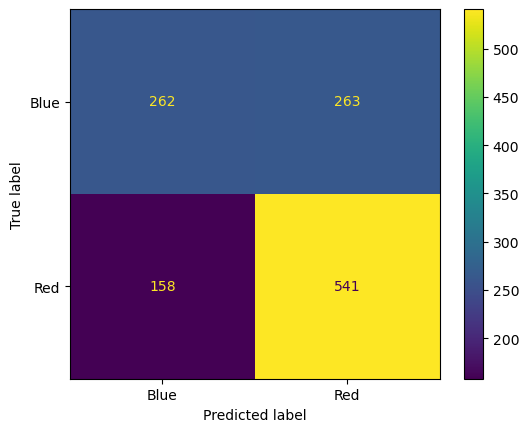

In [218]:
#Get Accuracy
accuracy = metrics.accuracy_score(y_valid, y_pred)
print(f'test_accuracy:{accuracy}')

#Display Confusion Matrix
cm = metrics.confusion_matrix(y_valid, y_pred, labels=model.classes_)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)

#Display CM
cm_display.plot()
plt.show()

Assess the most significant features

Text(0.5, 0, 'Random Forest Feature Importance Sort')

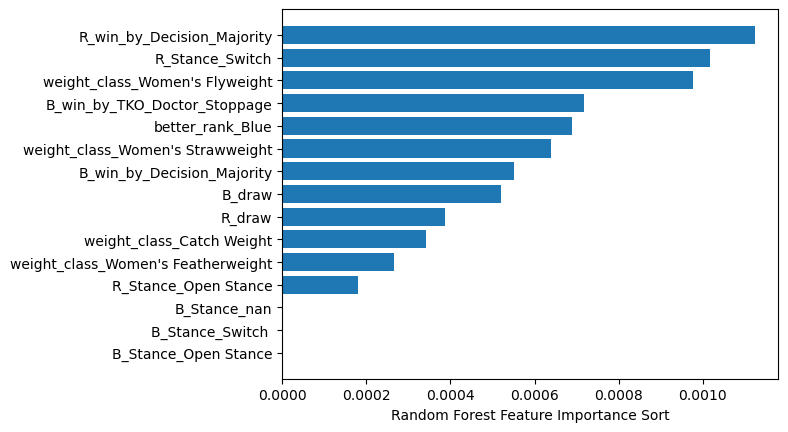

In [219]:
#feature_importances=pd.DataFrame({'features':X.columns,'feature_importance':best_grid.feature_importances_})
feature_importances=pd.DataFrame({'features':X_train.columns,'feature_importance':model.feature_importances_})
sorted_idx = model.feature_importances_.argsort()
sorted_idx_15 = sorted_idx[:15]
plt.barh(feature_importances.features[sorted_idx_15], model.feature_importances_[sorted_idx_15])
plt.xlabel("Random Forest Feature Importance Sort")

Predict Winners for upcoming event

In [220]:
#From the most accurate model, use this data to predict the winner of a more recent card
upcoming_event = pd.read_csv('data/upcoming-event.csv')

upcoming_event.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Mackenzie Dern,Marina Rodriguez,-195,165,51.282051,165.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Women's Strawweight,FEMALE,5,0,2,2,4.89,0.48,0.1,0.28,0.33,2,1,23,0,0,0,3,2,0,0,5,Orthodox,167.64,165.10,115,0,4,0,3.64,0.38,2.3,0.51,0.10,4,1,13,0,0,1,1,0,4,0,6,Orthodox,162.56,160.02,115,28,34,0,-2,-2,-1,0,10,0,2,-4,5.08,5.08,6,1.25,-2.2,-0.23,1,1,6.0,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,NaN,NaN,NaN,NaN,NaN,500,400.0,100,2800.0,900,380.0
1,Randy Brown,Jared Gooden,-265,215,37.735849,215.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Welterweight,MALE,3,0,1,0,5.04,0.42,0.0,0.96,1.00,1,2,7,0,0,0,0,1,0,0,1,Orthodox,182.88,195.58,170,0,1,0,3.72,0.47,0.7,0.98,0.46,2,4,26,0,0,0,2,2,3,0,7,Orthodox,190.50,198.12,170,31,27,0,0,-1,-6,-2,-19,0,-1,-3,-7.62,-2.54,-4,1.32,-0.7,-0.02,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,NaN,NaN,NaN,NaN,NaN,200,550.0,400,1600.0,215,500.0
2,Tim Elliott,Matheus Nicolau,155,-180,155.000000,55.555556,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Flyweight,MALE,3,0,1,0,3.79,0.52,1.4,1.93,0.44,3,1,13,0,0,2,1,0,1,0,4,Orthodox,167.64,167.64,125,0,2,0,3.35,0.45,1.1,4.01,0.49,2,9,39,1,0,0,5,0,1,0,6,Southpaw,170.18,167.64,125,34,28,0,-1,1,-2,-8,-26,-1,0,0,-2.54,0.00,-6,0.44,0.3,-2.08,1,1,11.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,Red,NaN,NaN,NaN,NaN,NaN,240,120.0,800,450.0,1600,650.0
3,Sabina Mazo,Mariya Agapova,-190,160,52.631579,160.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Women's Flyweight,FEMALE,3,1,0,0,3.70,0.50,0.6,1.23,0.66,1,2,6,0,0,0,0,0,1,0,1,Southpaw,167.64,172.72,125,1,0,0,6.56,0.44,0.2,0.81,0.80,3,2,15,0,0,1,1,0,1,0,3,Orthodox,170.18,177.80,125,24,24,0,0,-2,-2,0,-9,0,0,0,-2.54,-5.08,0,-2.86,0.4,0.42,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,NaN,NaN,NaN,NaN,

In [221]:

#Create new features
clean_upcoming_event = pd.DataFrame(data=upcoming_event, columns = my_cols)

#Drop Winner 
clean_upcoming_event = clean_upcoming_event.drop(axis= 1, labels=['Winner'])

#Preview
clean_upcoming_event.head()

,R_odds,B_odds,R_ev,B_ev,country,location,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_diftotal_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Pound-for-Pound_rank,B_Pound-for-Pound_rank,B_avg_TD_landed,B_avg_TD_pct,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,weight_class,gender,title_bout,better_rank
0,-195,165,51.282051,165.000000,USA,"Las Vegas, Nevada, USA",5,0,2,2,4.89,0.48,0.1,2,1,23,0,0,0,3,2,0,0,5,Orthodox,167.64,165.10,115,0,4,0,3.64,0.38,2.3,0.51,0.10,4,1,13,0,0,1,1,0,4,0,6,Orthodox,162.56,160.02,115,28,34,0,-2,-2,-1,NaN,0,2,-4,5.08,5.08,6,1.25,-2.2,-0.23,1,6.0,4.0,12.0,NaN,0.28,0.33,500,400.0,100,2800.0,900,380.0,Women's Strawweight,FEMALE,False,Red
1,-265,215,37.735849,215.000000,USA,"Las Vegas, Nevada, USA",3,0,1,0,5.04,0.42,0.0,1,2,7,0,0,0,0,1,0,0,1,Orthodox,182.88,195.58,170,0,1,0,3.72,0.47,0.7,0.98,0.46,2,4,26,0,0,0,2,2,3,0,7,Orthodox,190.50,198.12,170,31,27,0,0,-1,-6,NaN,0,-1,-3,-7.62,-2.54,-4,1.32,-0.7,-0.02,1,NaN,NaN,NaN,NaN,0.96,1.00,200,550.0,400,1600.0,215,500.0,Welterweight,MALE,False,neither
2,155,-180,155.000000,55.555556,USA,"Las Vegas, Nevada, USA",3,0,1,0,3.79,0.52,1.4,3,1,13,0,0,2,1,0,1,0,4,Orthodox,167.64,167.64,125,0,2,0,3.35,0.45,1.1,4.01,0.49,2,9,39,1,0,0,5,0,1,0,6,Southpaw,170.18,167.64,125,34,28,0,-1,1,-2,NaN,-1,0,0,-2.54,0.00,-6,0.44,0.3,-2.08,1,11.0,9.0,NaN,NaN,1.93,0.44,240,120.0,800,450.0,1600,650.0,Flyweight,MALE,False,Red
3,-190,160,52.631579,160.000000,USA,"Las Vegas, Nevada, USA",3,1,0,0,3.70,0.50,0.6,1,2,6,0,0,0,0,0,1,0,1,Southpaw,167.64,172.72,125,1,0,0,6.56,0.44,0.2,0.81,0.80,3,2,15,0,0,1,1,0,1,0,3,Orthodox,170.18,177.80,125,24,24,0,0,-2,-2,NaN,0,0,0,-2.54,-5.08,0,-2.86,0.4,0.42,1,NaN,NaN,NaN,NaN,1.23,0.66,130,350.0,800,800.0,350,750.0,Women's Flyweight,FEMALE,False,neither
4,-235,190,42.553191,190.000000,USA,"Las Vegas, Nevada, USA",3,0,1,0,2.15,0.51,0.8,1,2,12,0,0,1,1,0,0,0,2,Orthodox,172.72,175.26,135,0,4,1,4.30,0.57,0.2,0.57,0.60,3,1,16,0,0,1,2,1,0,0,4,Orthodox,175.26,170.18,145,30,27,0,-3,-2,-2,NaN,0,-1,0,-2.54,5.08,-3,-2.15,0.6,1.43,1,NaN,NaN,NaN,NaN,2.00,0.23,-110,400.0,1000,600.0,400,1200.0,Bantamweight,MALE,False,neither


In [222]:
#Clean Up dataset
clean_upcoming_event = clean_upcoming_event.fillna(0)

In [223]:
#Predict Winners 
winners = model.predict(clean_upcoming_event)

#Merge Dataframes
upcoming_event['Predicted Winner'] = winners

#info
predictions = upcoming_event.loc[:, ['R_fighter', 'B_fighter', 'Predicted Winner']]

#Show Outcomes 
print(predictions)

/Users/donaldkinyafisher/miniconda3/envs/ufc_env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- B_Pound-for-Pound_rank
- B_Stance
- B_match_weightclass_rank
- R_Pound-for-Pound_rank
- R_Stance
- ...
Feature names seen at fit time, yet now missing:
- B_Stance_Open Stance
- B_Stance_Orthodox
- B_Stance_Southpaw
- B_Stance_Switch
- B_Stance_Switch 
- ...

  warnings.warn(message, FutureWarning)


ValueError: could not convert string to float: 'USA'